In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


In [15]:
df = sns.load_dataset('mpg').dropna() # There are some rows with missing horsepower values , we drop them for convenience

In [16]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [20]:
# We will do all the test we ever do on a dataset to enure the linear model can make statistically confident predictions.

# 1) Multicollinearity Test 


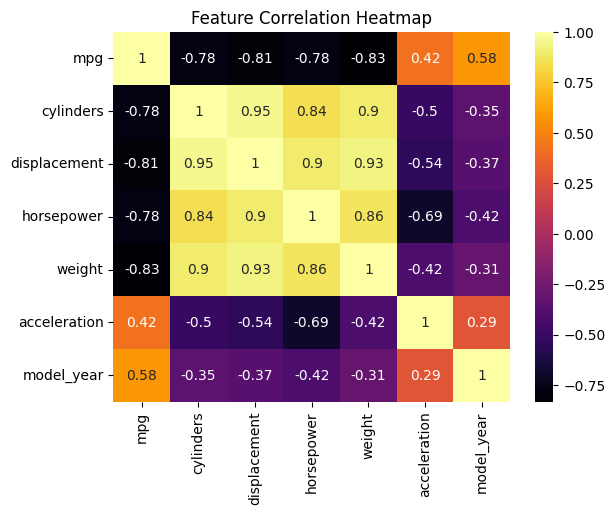

In [37]:
# We will first plot the heatmap of the features to look for any redundant cols correlating to each other and causing multicollinearity.
plt.title('Feature Correlation Heatmap')
sns.heatmap(df.drop(columns=['name','origin']).corr(),annot=True,cmap='inferno')
plt.show()

In [38]:
# A complete mess of correlated features

In [42]:
# Then we also do VIF test to see how each variable can or cannot be predicted by every other variables 
# Ranges from 0 - 5 can be tolerated , till or above ten means there is a huge correlation between this feature and other cols
# The actual range is from 1 - inf


# 1. Prepare your data (Separate your target variable)
# Replace 'target_column' with the actual name of your Y variable
X = df.drop(columns=['name','origin']) 

# 2. Add a constant intercept (Crucial: VIF requires an intercept to be accurate)
X_with_const = add_constant(X)

# 3. Calculate VIF for each feature using a list comprehension
vif_data = pd.DataFrame()
vif_data["features"] = X_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_with_const.values, i) 
    for i in range(X_with_const.shape[1])
]

# 4. Clean up the output
# Remove the constant row and sort by highest VIF
vif_data = vif_data[vif_data["features"] != 'const']
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

print(vif_data)


       features        VIF
0  displacement  19.697244
1        weight  13.598221
2     cylinders  10.660295
3    horsepower   9.398062
4           mpg   5.242609
5  acceleration   2.630344
6    model_year   1.907643


In [43]:
# As you can see these top features are heavily correlated and a specific measure for this need to be decided asap because
# if not it will affect model performance.